In [8]:
# =====================================================================
# Adım 1: IMPORTS & VERİ YÜKLEME
# =====================================================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score, classification_report, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)

if file_path is None:
    raise FileNotFoundError("CSV file not found. Please add the dataset to Kaggle!")

df = pd.read_csv(file_path)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

Dataset loaded successfully! Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
# =====================================================================
# Adım 2: DATA QUALITY ASSESSMENT (Veri Kalitesi ve Aykırı Değer Temizleme)
# =====================================================================
print("Missing values count:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Drop unnecessary columns
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = df.drop(columns=drop_cols, errors="ignore")
df['Attrition'] = df['Attrition'].astype(str).str.strip()

# Outlier Handling (Using IQR method for numerical columns)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("New shape after cleaning and outlier handling:", df.shape)

Missing values count: 0
Duplicate rows: 0
New shape after cleaning and outlier handling: (1470, 31)


In [10]:
# =====================================================================
# Adım 3: FEATURE ENGINEERING (Özellik Mühendisliği)
# =====================================================================
df["TotalSatisfaction"] = (
    df["JobSatisfaction"].fillna(0) +
    df["EnvironmentSatisfaction"].fillna(0) +
    df["RelationshipSatisfaction"].fillna(0) +
    df["WorkLifeBalance"].fillna(0)
)

df["IncomePerYear"] = df["MonthlyIncome"] * 12
df["YearsPerAge"] = df["TotalWorkingYears"] / (df["Age"] + 1)
df["TenureRatio"] = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)

print("New features added. Current shape:", df.shape)
df.head()

New features added. Current shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalSatisfaction,IncomePerYear,YearsPerAge,TenureRatio
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0.5,1,6,4.0,0.0,5.0,8,71916,0.190476,0.666667
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,3.0,3,10,7.0,1.0,7.0,12,61560,0.200000,0.909091
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3.0,3,0,0.0,0.0,0.0,12,25080,0.184211,0.000000
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3.0,3,8,7.0,3.0,0.0,13,34908,0.235294,0.888889
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3.0,3,2,2.0,2.0,2.0,10,41616,0.214286,0.285714


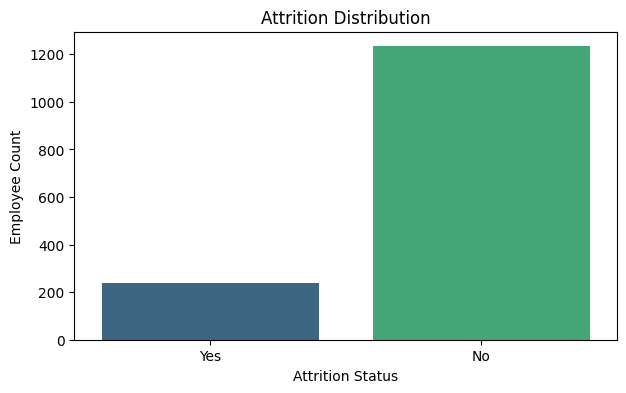

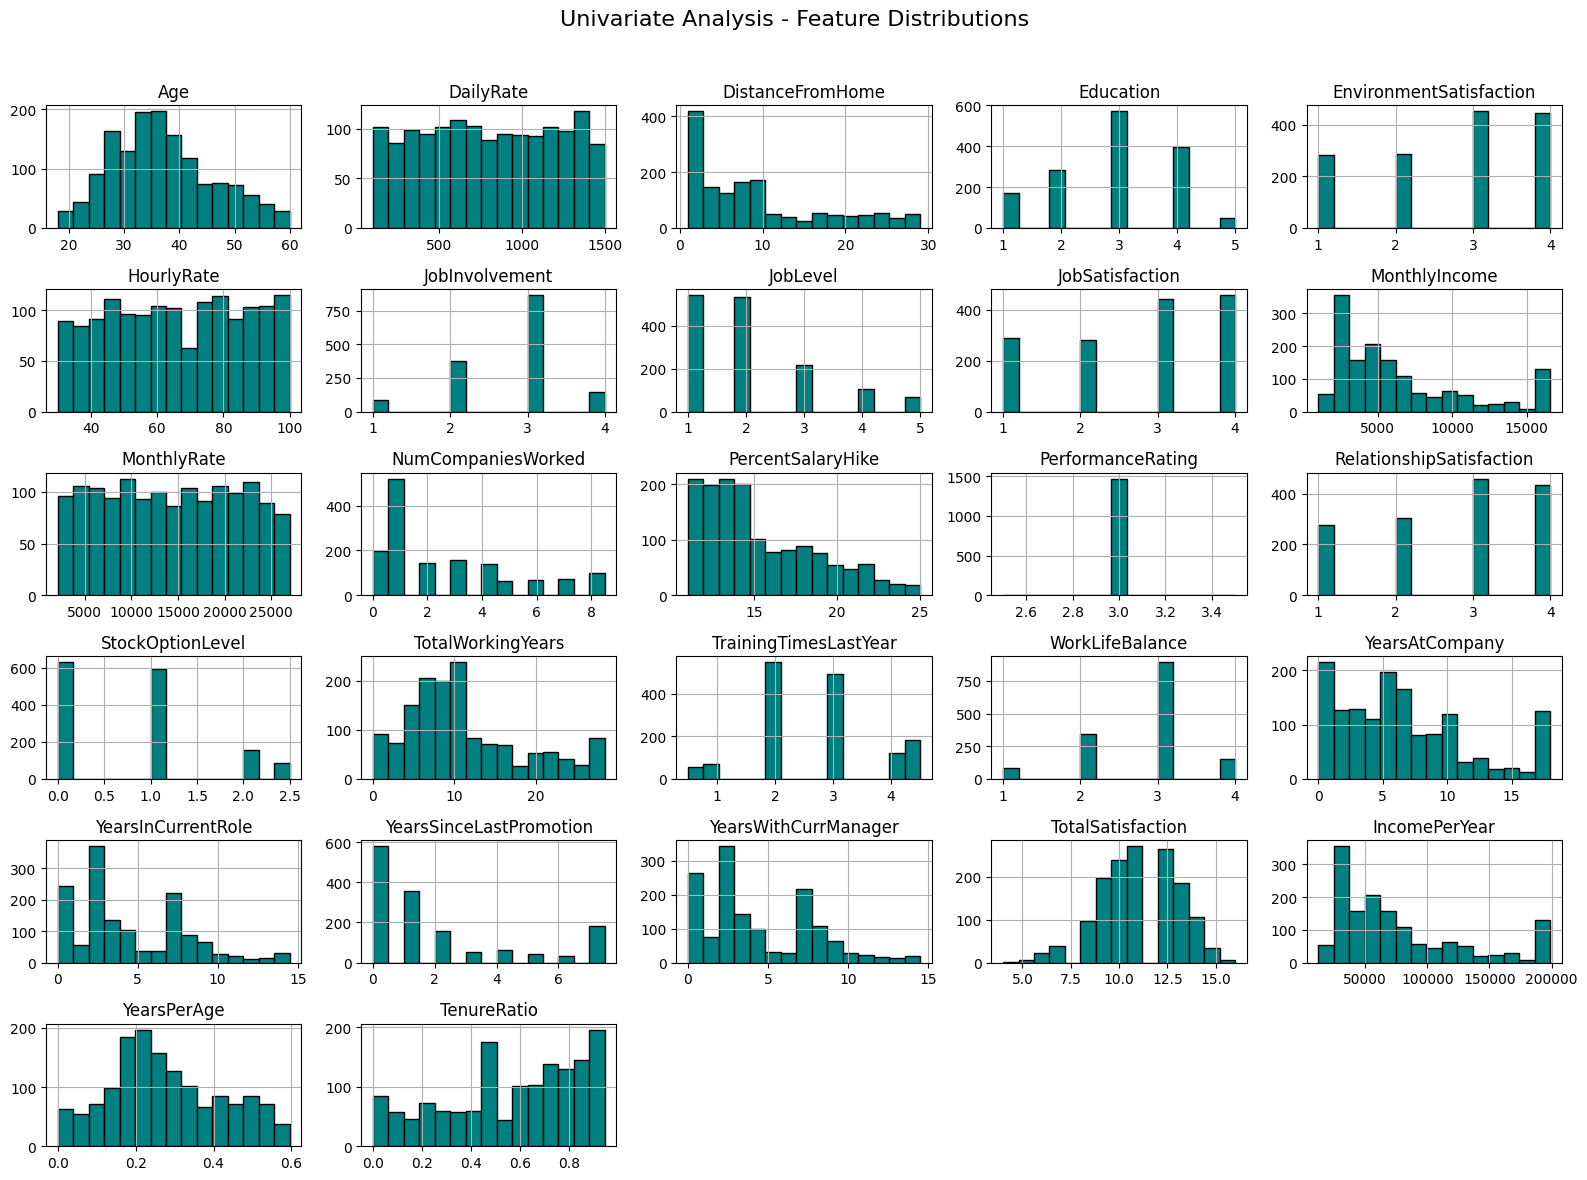

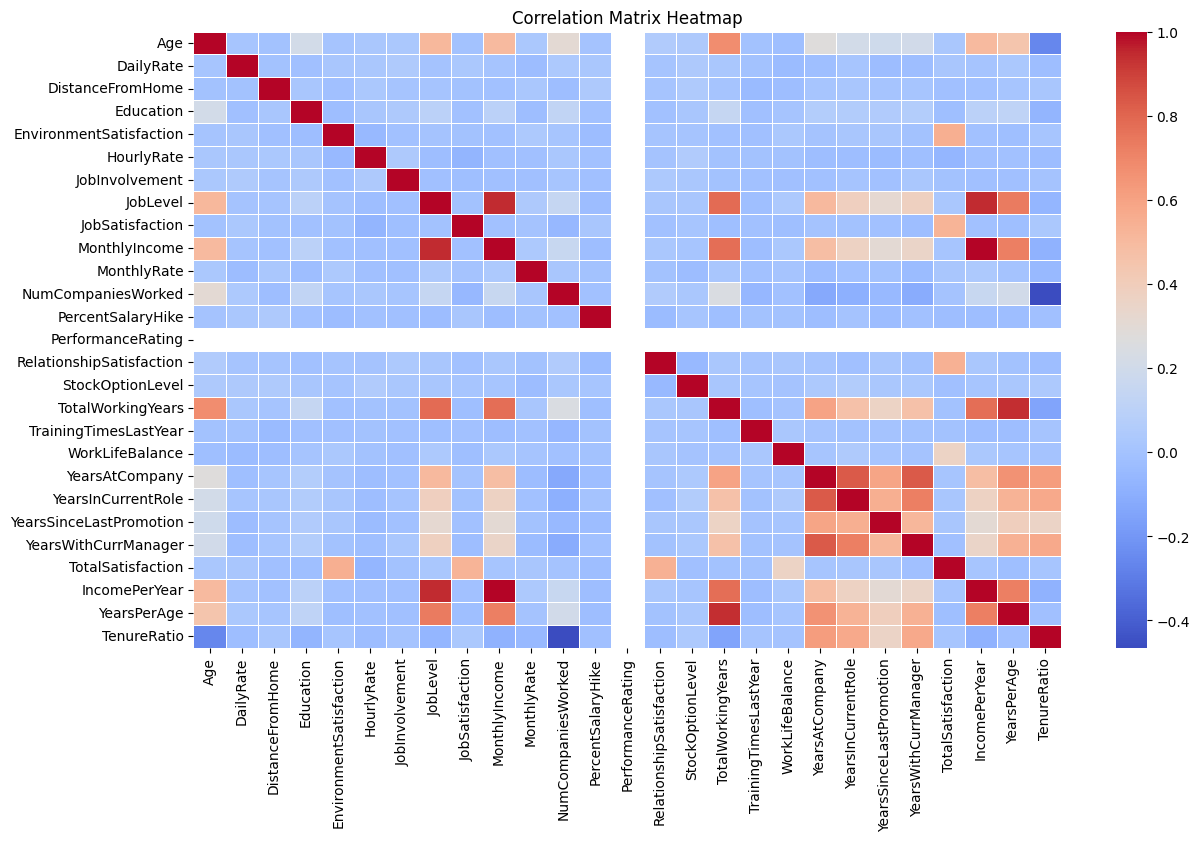

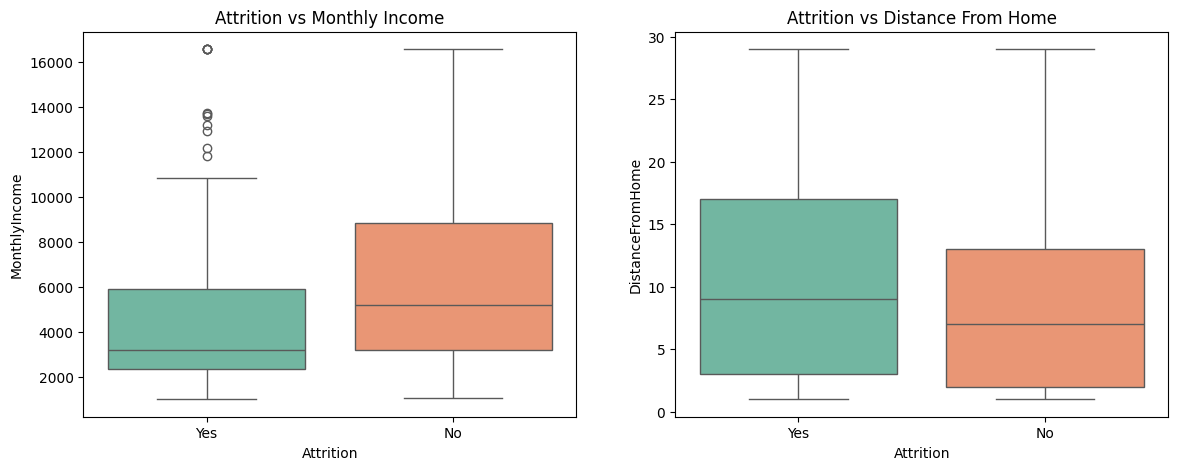

In [11]:
# =====================================================================
# Step  4: EDA & VISUALIZATION
# =====================================================================

# 1. Target Distribution
plt.figure(figsize=(7, 4))
sns.countplot(x="Attrition", data=df, palette="viridis")
plt.title("Attrition Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Employee Count")
plt.show()

# 2. Numerical Distributions (Histogram)
df.hist(bins=15, figsize=(16, 12), color='teal', edgecolor='black')
plt.suptitle("Univariate Analysis - Feature Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. Correlation Matrix (Heatmap)
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 4. Boxplots
income_data = df[['Attrition', 'MonthlyIncome']].dropna()
distance_data = df[['Attrition', 'DistanceFromHome']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=income_data, hue="Attrition", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Attrition vs Monthly Income")

sns.boxplot(x="Attrition", y="DistanceFromHome", data=distance_data, hue="Attrition", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Attrition vs Distance From Home")
plt.show()

In [12]:
# =====================================================================
# STEP 5: X VE Y SPLIT VE TRAIN-TEST SPLIT
# =====================================================================
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

valid_idx = y.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)

X_train shape: (1176, 34)


In [14]:
# =====================================================================
# Adım 6: ÖZELLİK SEÇİMİ (RFE) VE PIPELINE OLUŞTURMA
# =====================================================================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
])

# RFE (Özellik Seçimi) Uygulaması
# Logistic Regression'ı RFE için temel model olarak kullanıyoruz.
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
selector = RFE(estimator=log_reg, n_features_to_select=25, step=1)

print("Preprocessor and RFE setup complete.")

Preprocessor and RFE setup complete.


In [15]:
# =====================================================================
# Adım 7: MODEL EĞİTİMİ (XGBoost ile Dengeli Eğitim)
# =====================================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=700,
        max_depth=5,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

print("Training the model...")
xgb.fit(X_train, y_train)
print("Model training complete.")

Training the model...
Model training complete.



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.50      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.69      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294

Test F1-Score : 0.38961038961038963
Test ROC-AUC  : 0.7696614695494874

--- CROSS-VALIDATION RESULTS ---
CV F1 Scores: [0.51282051 0.45454545 0.525      0.56756757 0.5       ]
Mean CV F1 Score: 0.5120


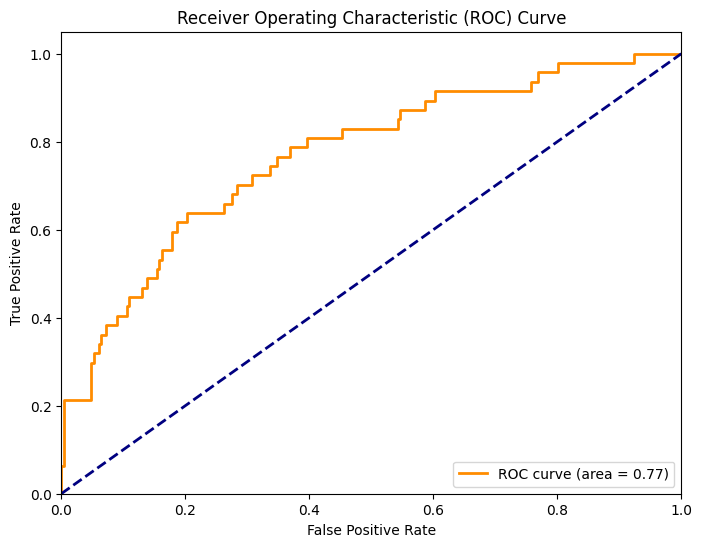

In [16]:
# =====================================================================
# Adım 8: METRİK DEĞERLENDİRMESİ VE ROC EĞRİSİ ÇİZİMİ
# =====================================================================
y_pred = xgb.predict(X_test)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print("Test F1-Score :", f1)
print("Test ROC-AUC  :", roc_auc)

# Çapraz Doğrulama
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring="f1")

print("\n--- CROSS-VALIDATION RESULTS ---")
print("CV F1 Scores:", cv_scores)
print("Mean CV F1 Score: %.4f" % cv_scores.mean())

# ROC Curve Görüntüsü
y_pred_proba = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_val)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

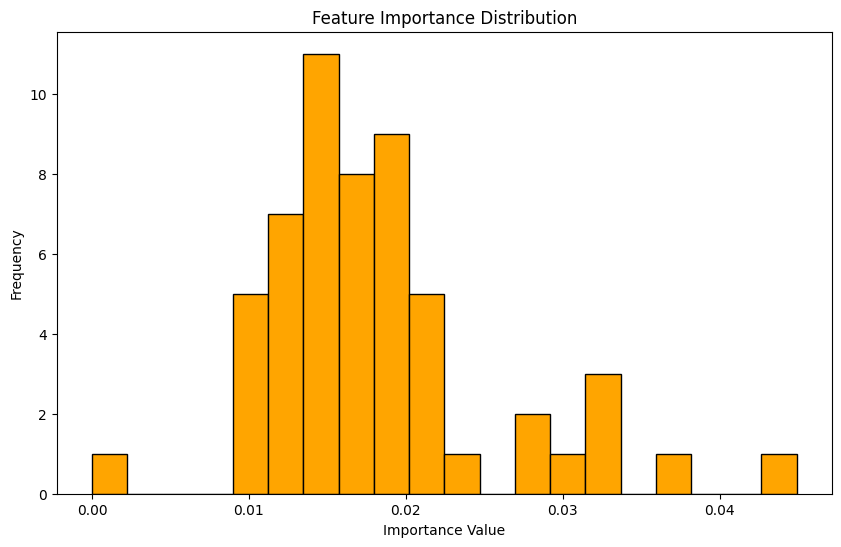

In [17]:
# =====================================================================
# Adım 9: FEATURE IMPORTANCE (Önem Dağılımı Dağılımı)
# =====================================================================
importance = xgb.named_steps["model"].feature_importances_

plt.figure(figsize=(10, 6))
plt.hist(importance, bins=20, color="orange", edgecolor="black")
plt.title("Feature Importance Distribution")
plt.xlabel("Importance Value")
plt.ylabel("Frequency")
plt.show()